In [33]:
import scanpy as sc
adata = sc.read_h5ad("../data/obesity_challenge_2.h5ad")

In [21]:
adata.obs[[
    "nCount_RNA",
    "nFeature_RNA",
    "percent.mt",
    'nCount_guide'
]].describe()

,nCount_RNA,nFeature_RNA,percent.mt,nCount_guide
count,90815.000000,90815.000000,90815.000000,90815.000000
mean,15541.215086,4068.735198,4.869922,23.709398
std,7465.811049,1109.703974,1.757228,18.207290
min,530.000000,353.000000,0.000000,3.000000
25%,9455.000000,3171.000000,3.707057,12.000000
50%,13726.000000,3877.000000,4.557141,19.000000
75%,20200.000000,4922.000000,5.663897,29.000000
max,74522.000000,8832.000000,14.990512,442.000000


In [4]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    subset=True
)

sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata)

In [5]:
sc.pp.neighbors(adata)

sc.tl.umap(adata)

/opt/anaconda3/envs/spatialhackathon/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
adata

AnnData object with n_obs × n_vars = 90815 × 3000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [9]:
adata.obs["batch"] = adata.obs_names.str.split("_").str[0]

adata.obs["batch"].value_counts()

batch
P6     7968
P3     7949
P12    7712
P5     7678
P8     7631
P7     7590
P2     7550
P9     7532
P10    7504
P4     7414
P1     7278
P11    7009
Name: count, dtype: int64

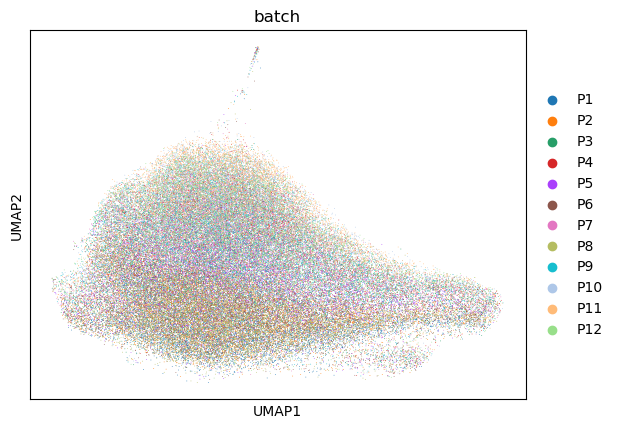

In [10]:
sc.pl.umap(
    adata,
    color="batch"
)

In [12]:
import pandas as pd

pd.crosstab(
    adata.obs["gene"],
    adata.obs["batch"]
)

batch,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12
gene,,,,,,,,,,,,
CEBPA+CEBPA,4,6,3,5,7,8,2,4,8,4,3,4
CEBPA+CEBPA+CEBPB,0,0,0,0,0,0,0,0,0,0,0,1
CEBPA+CEBPA+NR3C1,0,0,0,0,0,1,0,0,0,0,0,0
CEBPA+CEBPA+POLR2D,0,0,0,0,0,0,1,0,0,0,0,0
CEBPA+CEBPA+STAT5B,0,1,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
TCF7L2,791,775,896,751,819,793,803,814,768,756,700,807
TCF7L2+TCF7L2,2,2,3,2,2,3,3,2,2,5,4,1
TCF7L2+ZBED3,3,5,10,5,4,13,5,8,5,6,3,3


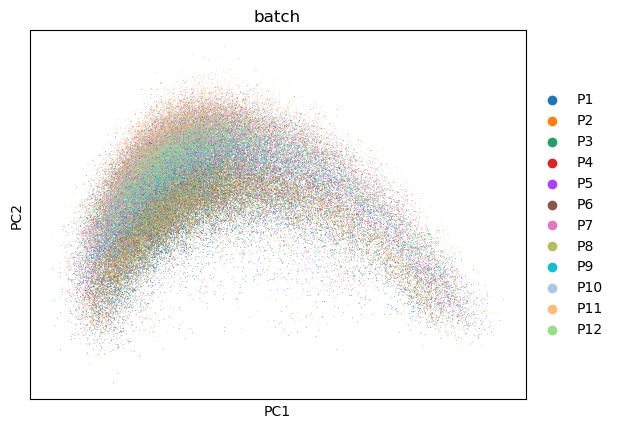

In [13]:
sc.pl.pca(
    adata,
    color="batch"
)

In [22]:
vc = adata.obs["gene"].value_counts()

all_perts = set(vc.index.astype(str))

# singles (不含 +)
single_perts = sorted([p for p in all_perts if "+" not in p])

# combos
combo_perts = sorted([p for p in all_perts if "+" in p])

In [23]:
controls = ["NC", "NC+NC"]

controls_present = [c for c in controls if c in all_perts]

print(controls_present)

['NC', 'NC+NC']


In [24]:
from itertools import combinations

valid_pairs = []

for g1, g2 in combinations(single_perts, 2):

    combo_name1 = f"{g1}+{g2}"
    combo_name2 = f"{g2}+{g1}"

    if combo_name1 in all_perts or combo_name2 in all_perts:
        valid_pairs.append((g1, g2))
        
print("可用 gene pairs 數量:", len(valid_pairs))

valid_pairs[:10]


可用 gene pairs 數量: 34


[('CEBPB', 'KIF11'),
 ('CEBPB', 'NC'),
 ('CEBPB', 'NR3C1'),
 ('CEBPB', 'POLR2D'),
 ('CEBPB', 'SF3B1'),
 ('CEBPB', 'STAT5B'),
 ('CEBPB', 'TCF7L2'),
 ('KIF11', 'NC'),
 ('KIF11', 'NR3C1'),
 ('KIF11', 'SF3B1')]

In [26]:
g1, g2 = valid_pairs[0]

selected_perts = [
    "NC",
    "NC+NC",
    g1,
    g2,
    f"{g1}+{g2}",
    f"{g1}+NC",
    f"{g2}+NC"

]

selected_perts

['NC', 'NC+NC', 'CEBPB', 'KIF11', 'CEBPB+KIF11', 'CEBPB+NC', 'KIF11+NC']

In [34]:
adata_subset = adata[
    adata.obs["gene"].isin(selected_perts)
].copy()

adata_subset.obs["gene"].value_counts()

gene
CEBPB          10782
NC              8660
KIF11           4705
CEBPB+NC          82
CEBPB+KIF11       42
NC+NC             28
KIF11+NC          26
Name: count, dtype: int64

In [36]:
adata_subset

AnnData object with n_obs × n_vars = 24325 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'

In [37]:
import pandas as pd

pd.crosstab(
    adata_subset.obs["gene"],
    adata_subset.obs["SampleID"]
)

SampleID,TF15_MOI2_1,TF15_MOI2_2,TF15_MOI2_3,TF15_MOI2_4,TF15_MOI2_5,TF15_MOI2_6,TF15_MOI2_7,TF15_MOI2_8,TF15_MOI2_9,TF15_MOI2_10,TF15_MOI2_11,TF15_MOI2_12
gene,,,,,,,,,,,,
CEBPB,840,819,993,919,870,913,901,920,898,900,871,938
CEBPB+KIF11,1,5,4,4,2,1,4,2,4,6,5,4
CEBPB+NC,7,3,7,4,7,12,7,6,8,11,5,5
KIF11,386,432,366,394,382,407,387,412,409,375,343,412
KIF11+NC,2,4,1,2,5,2,2,2,3,0,2,1
NC,735,735,712,705,744,765,731,691,727,673,700,742
NC+NC,1,4,2,3,2,5,4,0,2,3,0,2


In [38]:
adata_subset.write_h5ad("../data/obesity_subset_CEBPB_KIF11.h5ad")